##Setup

In [1]:
!pip install gymnasium shimmy ale-py
!pip install autorom
!AutoROM -y

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/opt/anaconda3/lib/python3.13/site-packages/AutoROM/roms

Existing ROMs will be overwritten.


In [2]:
"""
live_plot.py — drop-in live metrics dashboard for Go-Explore notebooks.

Usage
-----
from live_plot import MetricsDashboard

dashboard = MetricsDashboard(metrics=['max_reward', 'cells', 'loss', 'entropy'])

# inside your training loop, replace print(...) with:
dashboard.update(
    iteration   = iterations,
    frames      = frames,
    max_reward  = highscore,
    cells       = len(archive),
    loss        = loss,
    entropy     = entropy,   # omit kwargs that don't apply to your algorithm
)
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from IPython import display as ipydisplay
from collections import defaultdict
import numpy as np

# ── Aesthetic config ──────────────────────────────────────────────────────────
BG       = '#0d1117'
PANEL_BG = '#161b22'
GRID_COL = '#21262d'
TEXT     = '#e6edf3'
MUTED    = '#8b949e'
BORDER   = '#30363d'

PALETTE = [
    '#58a6ff',   # blue       — max_reward
    '#3fb950',   # green      — cells
    '#f78166',   # red-orange — loss
    '#d2a8ff',   # lavender   — entropy
    '#ffa657',   # amber      — actor_loss
    '#79c0ff',   # light blue — critic_loss
]

# Human-readable labels for known metric keys
LABELS = {
    'max_reward'  : 'Max Reward',
    'cells'       : 'Archive Cells',
    'loss'        : 'Loss',
    'entropy'     : 'Entropy',
    'actor_loss'  : 'Actor Loss',
    'critic_loss' : 'Critic Loss',
    'epsilon'     : 'Epsilon',
    'frames'      : 'Frames',
}


class MetricsDashboard:
    """
    Live-updating matplotlib dashboard for Jupyter notebooks.

    Parameters
    ----------
    metrics : list[str]
        Names of the metrics to plot, e.g. ['max_reward', 'cells', 'loss'].
        Each gets its own subplot panel.
    title : str
        Dashboard title shown at the top.
    update_every : int
        Redraw the figure every N calls to .update(). Higher = faster training,
        less smooth graph. Default 1 redraws every iteration.
    window : int | None
        If set, only the last `window` iterations are shown (rolling view).
        None shows the full history.
    """

    def __init__(
        self,
        metrics       : list,
        title         : str  = 'Go-Explore Training',
        update_every  : int  = 1,
        window        : int | None = None,
    ):
        if not metrics:
            raise ValueError('Provide at least one metric name.')

        self.metrics      = metrics
        self.title        = title
        self.update_every = update_every
        self.window       = window
        self._call_count  = 0

        # History stores: iteration index + one list per metric
        self._iters : list[int]            = []
        self._data  : dict[str, list[float]] = defaultdict(list)

        matplotlib.rcParams.update({
            'font.family'      : 'monospace',
            'axes.facecolor'   : PANEL_BG,
            'figure.facecolor' : BG,
            'text.color'       : TEXT,
            'axes.labelcolor'  : MUTED,
            'xtick.color'      : MUTED,
            'ytick.color'      : MUTED,
            'axes.edgecolor'   : BORDER,
            'axes.grid'        : True,
            'grid.color'       : GRID_COL,
            'grid.linewidth'   : 0.6,
            'axes.spines.top'  : False,
            'axes.spines.right': False,
        })

        n    = len(metrics)
        cols = min(n, 2)
        rows = (n + 1) // 2

        self._fig = plt.figure(
            figsize    = (7 * cols, 3.2 * rows + 0.8),
            facecolor  = BG,
        )

        # Title row + metric panels
        outer = gridspec.GridSpec(
            2, 1,
            figure       = self._fig,
            height_ratios= [0.18, 1],
            hspace       = 0.05,
        )
        inner = gridspec.GridSpecFromSubplotSpec(
            rows, cols,
            subplot_spec = outer[1],
            hspace       = 0.55,
            wspace       = 0.35,
        )

        # Header panel (text only)
        self._header_ax = self._fig.add_subplot(outer[0])
        self._header_ax.axis('off')
        self._title_text = self._header_ax.text(
            0.5, 0.45, title,
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=15, fontweight='bold',
            color=TEXT, fontfamily='monospace',
        )
        self._subtitle_text = self._header_ax.text(
            0.5, -0.25, '',
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=9, color=MUTED, fontfamily='monospace',
        )

        # One subplot per metric
        self._axes = []
        self._lines = []
        for idx, metric in enumerate(metrics):
            row, col = divmod(idx, cols)
            ax = self._fig.add_subplot(inner[row, col])
            ax.set_title(
                LABELS.get(metric, metric),
                fontsize=10, color=MUTED,
                pad=6, loc='left',
            )
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.tick_params(labelsize=7)

            color = PALETTE[idx % len(PALETTE)]
            (line,) = ax.plot([], [], color=color, linewidth=1.6, antialiased=True)

            # Subtle fill under the curve
            ax.fill_between([], [], color=color, alpha=0.08)

            self._axes.append(ax)
            self._lines.append(line)

        # Hide any unused subplot slots
        for idx in range(len(metrics), rows * cols):
            row, col = divmod(idx, cols)
            self._fig.add_subplot(inner[row, col]).set_visible(False)

        plt.close(self._fig)   # Don't show yet; we control display manually

    # ─────────────────────────────────────────────────────────────────────────
    def update(self, iteration: int, frames: int = 0, **metric_values):
        """
        Record one data point and optionally redraw.

        Parameters
        ----------
        iteration : int
            Current training iteration (x-axis).
        frames : int
            Total environment frames so far (shown in subtitle).
            If 'frames' is also listed in the `metrics` list passed to
            __init__, it will be plotted as a panel too — the named parameter
            and the plottable metric are the same value.
        **metric_values
            Keyword arguments matching the `metrics` list passed to __init__.
            Unknown keys are silently ignored.
        """
        # FIX: 'frames' is an explicit named parameter used for the subtitle,
        # so passing frames=N never reaches **metric_values — it gets consumed
        # by the signature before ** sees it. If the user listed 'frames' as a
        # metric to plot, inject it back into the lookup dict here.
        if 'frames' in self.metrics:
            metric_values = {**metric_values, 'frames': frames}

        self._iters.append(iteration)
        for metric in self.metrics:
            value = metric_values.get(metric, float('nan'))
            self._data[metric].append(float(value))

        self._call_count += 1
        if self._call_count % self.update_every == 0:
            self._redraw(frames)

    # ─────────────────────────────────────────────────────────────────────────
    def _redraw(self, frames: int):
        iters = np.array(self._iters)

        if self.window is not None and len(iters) > self.window:
            iters = iters[-self.window:]
            data  = {m: self._data[m][-self.window:] for m in self.metrics}
        else:
            data = self._data

        # Update subtitle
        latest = {m: data[m][-1] for m in self.metrics if data[m]}
        parts  = [f'iter {iters[-1]:,}', f'frames {frames:,}']
        parts += [f"{LABELS.get(m, m)}: {v:.3g}" for m, v in latest.items()]
        #self._subtitle_text.set_text('  ·  '.join(parts))

        for ax, line, metric in zip(self._axes, self._lines, self.metrics):
            y = np.array(data[metric], dtype=float)

            # Remove old fill_between collections and redraw
            for coll in ax.collections:
                coll.remove()

            line.set_data(iters, y)

            color = line.get_color()
            ax.fill_between(iters, y, alpha=0.08, color=color)

            # Tight axis limits with padding
            valid = y[np.isfinite(y)]
            if len(valid) >= 2:
                ymin, ymax = valid.min(), valid.max()
                pad = (ymax - ymin) * 0.12 or 0.5
                ax.set_ylim(ymin - pad, ymax + pad)

            if len(iters) >= 2:
                ax.set_xlim(iters[0], iters[-1])

        ipydisplay.clear_output(wait=True)
        ipydisplay.display(self._fig)

    def final(self):
        """Call once at the end of training to ensure the final state is shown."""
        self._redraw(frames=self._iters[-1] if self._iters else 0)

def get_lives(env):
    """
    Read the current number of lives directly from the ALE emulator,
    bypassing the Gymnasium wrapper entirely.

    Why this matters:
    - Montezuma's Revenge reports info['lives'] as lives *remaining after
      the current one*, so a fresh episode starts at 5, not 6.
    - Checking `info['lives'] < 6` is therefore always True, terminating
      every episode on step 1 and freezing archive growth at ~8 cells.
    - After ale.restoreState() the wrapper's internal counter is stale
      (it only updates through env.reset()), making info['lives'] wrong
      for the entire restored episode too.
    - env.unwrapped.ale.lives() always reflects the true ALE state
      regardless of how the state was set.

    Usage pattern in training loop:
        current_lives = get_lives(env)          # after reset or restore
        ...
        new_lives = get_lives(env)              # after env.step()
        life_lost = new_lives < current_lives   # relative decrease only
        current_lives = new_lives
    """
    return env.unwrapped.ale.lives()

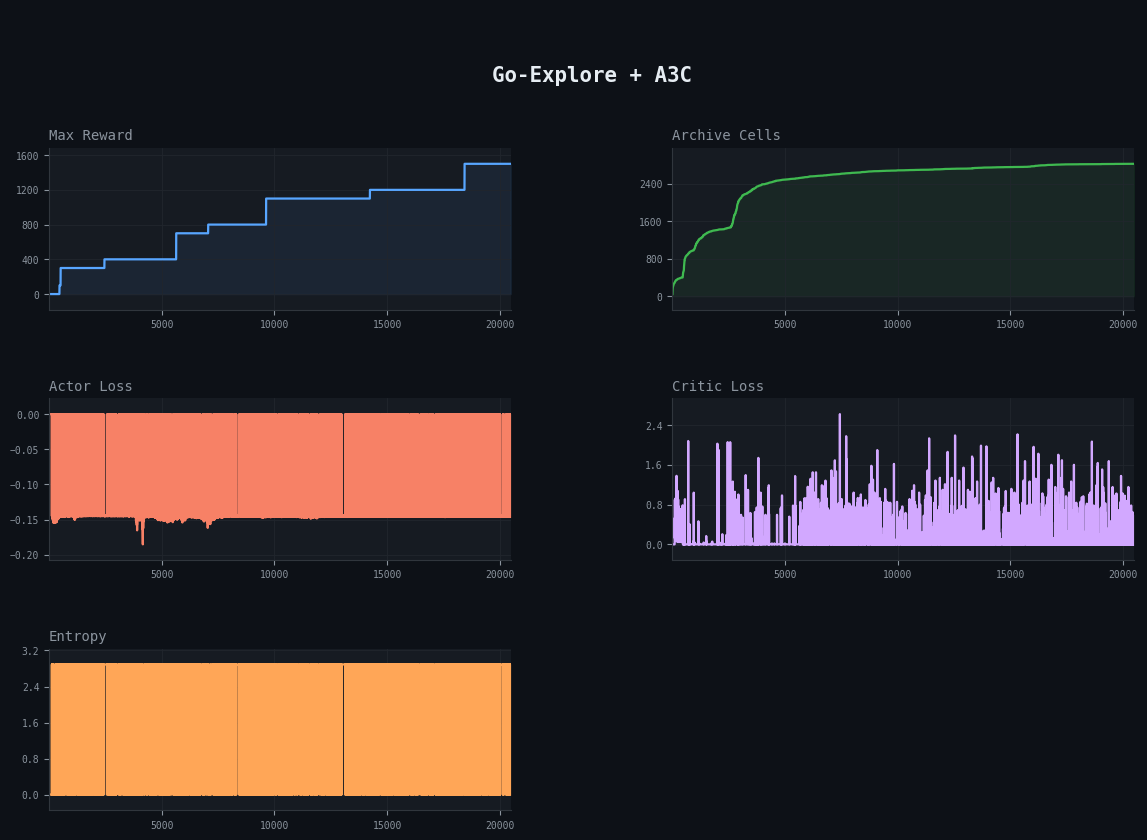

In [ ]:
from collections import defaultdict
import numpy as np
import cv2
import gymnasium as gym
from gymnasium.vector import SyncVectorEnv
import ale_py
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os

dashboard = MetricsDashboard(
    metrics=['max_reward', 'cells', 'actor_loss', 'critic_loss', 'entropy'],
    title='Go-Explore + A3C',
    update_every=10,
)

# ──────────────────────────────────────────────
# Rendering
# ──────────────────────────────────────────────
def render_env(envs, env_idx=0, iteration=0):
    frame = envs.envs[env_idx].render()
    save_dir = 'renders'
    os.makedirs(save_dir, exist_ok=True)
    plt.imshow(frame)
    plt.axis('off')
    plt.savefig(os.path.join(save_dir, f'frame_{iteration:05d}.png'))
    plt.close()

# ──────────────────────────────────────────────
# Go-Explore cell functions (pixel-based)
# ──────────────────────────────────────────────
def cellfn(frame):
    cell = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    cell = cv2.resize(cell, (11, 8), interpolation=cv2.INTER_AREA)
    cell = cell // 32
    return cell

def hashfn(cell):
    return hash(cell.tobytes())

# ──────────────────────────────────────────────
# Go-Explore archive
# ──────────────────────────────────────────────
e1 = 0.001
e2 = 0.00001

class Weights:
    times_chosen           = 0.1
    times_chosen_since_new = 0.0
    times_seen             = 0.3

class Powers:
    times_chosen           = 0.5
    times_chosen_since_new = 0.5
    times_seen             = 0.5

class Cell:
    def __init__(self):
        self.times_chosen           = 0
        self.times_chosen_since_new = 0
        self.times_seen             = 0

    def __setattr__(self, key, value):
        object.__setattr__(self, key, value)
        if key != 'score' and hasattr(self, 'times_seen'):
            self.score = self.cellscore()

    def cntscore(self, a):
        w = getattr(Weights, a)
        p = getattr(Powers, a)
        v = getattr(self, a)
        return w / (v + e1) ** p + e2

    def cellscore(self):
        return (self.cntscore('times_chosen') +
                self.cntscore('times_chosen_since_new') +
                self.cntscore('times_seen') + 1)

    def visit(self):
        self.times_seen += 1
        return self.times_seen == 1

    def choose(self):
        self.times_chosen           += 1
        self.times_chosen_since_new += 1
        return self.ram, self.reward, self.trajectory


# ──────────────────────────────────────────────
# Count-based intrinsic reward
#
# r_intrinsic(s) = β / sqrt(N(s))
#
# N(s) = cell.times_seen, incremented by visit() before this is called,
# so the first visit yields the maximum bonus β.
#
# Intrinsic reward is added to the rewards array fed into A3C ONLY.
# It is never added to current_scores or highscore, which always
# reflect true game reward so the archive and dashboard remain
# comparable across all experiments.
# ──────────────────────────────────────────────
INTRINSIC_BETA = 0.01

def intrinsic_reward(cell):
    """β / sqrt(N(s)). Returns 0 on terminal steps (no cell visited)."""
    return INTRINSIC_BETA / max(cell.times_seen, 1) ** 0.5


# ──────────────────────────────────────────────
# Running return normaliser
# ──────────────────────────────────────────────
class RunningNormaliser:
    def __init__(self, clip=10.0):
        self.mean  = 0.0
        self.var   = 1.0
        self.count = 0
        self.clip  = clip

    def update(self, x: torch.Tensor):
        batch_mean = x.mean().item()
        batch_var  = x.var().item() if x.numel() > 1 else 0.0
        batch_n    = x.numel()
        n          = self.count + batch_n
        delta      = batch_mean - self.mean
        self.mean  += delta * batch_n / n
        self.var    = (self.var * self.count + batch_var * batch_n +
                       delta ** 2 * self.count * batch_n / n) / n
        self.count  = n

    def normalise(self, x: torch.Tensor) -> torch.Tensor:
        self.update(x)
        return ((x - self.mean) / (self.var ** 0.5 + 1e-8)).clamp(-self.clip, self.clip)


# ──────────────────────────────────────────────
# Networks
# ──────────────────────────────────────────────
class Actor(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        self.conv1 = nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            x = F.relu(self.conv1(dummy))
            x = F.relu(self.conv2(x))
            x = F.relu(self.conv3(x))
            self._feature_size = x.reshape(1, -1).size(1)
        self.fc = nn.Linear(self._feature_size, n_actions)

    def forward(self, x):
        x = x.float() / 255.
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        return F.softmax(self.fc(x.reshape(x.size(0), -1)), dim=-1)


class Critic(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.conv1 = nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            x = F.relu(self.conv1(dummy))
            x = F.relu(self.conv2(x))
            x = F.relu(self.conv3(x))
            self._feature_size = x.reshape(1, -1).size(1)
        self.fc = nn.Linear(self._feature_size, 1)

    def forward(self, x):
        x = x.float() / 255.
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        return self.fc(x.reshape(x.size(0), -1))


# ──────────────────────────────────────────────
# A3C Agent
# ──────────────────────────────────────────────
class A3CAgent:
    def __init__(self, envs, gamma=0.99, lr=1e-4, entropy_coef=0.05, grad_clip=0.5):
        self.num_envs          = envs.num_envs
        self.action_space_size = envs.single_action_space.n
        obs_shape              = envs.single_observation_space.shape  # (H, W, C)
        self.input_shape       = (obs_shape[2], obs_shape[0], obs_shape[1])

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Using device: {self.device}')

        self.actor  = Actor(self.input_shape, self.action_space_size).to(self.device)
        self.critic = Critic(self.input_shape).to(self.device)

        self.actor_optimizer  = optim.Adam(self.actor.parameters(),  lr=lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr)

        self.gamma        = gamma
        self.entropy_coef = entropy_coef
        self.grad_clip    = grad_clip
        self.return_norm  = RunningNormaliser(clip=10.0)

    def preprocess(self, states):
        return torch.from_numpy(states).permute(0, 3, 1, 2).to(self.device)

    def select_action(self, states):
        with torch.no_grad():
            probs = self.actor(self.preprocess(states))
        actions = torch.distributions.Categorical(probs).sample()
        return actions.cpu().numpy()

    def update_model(self, states_batch, actions_batch, rewards_batch,
                     dones_batch, policy_mask_batch):
        """
        rewards_batch contains extrinsic + intrinsic combined reward.
        The critic and actor learn from this combined signal.
        """
        num_steps = len(states_batch)

        flat_states  = torch.cat([self.preprocess(s) for s in states_batch], dim=0)
        flat_actions = torch.tensor(np.concatenate(actions_batch),
                                    dtype=torch.long).to(self.device)
        flat_rewards = torch.tensor(np.concatenate(rewards_batch),
                                    dtype=torch.float32).to(self.device)
        flat_dones   = torch.tensor(np.concatenate(dones_batch).astype(np.float32)
                                    ).to(self.device)
        flat_mask    = torch.tensor(np.concatenate(policy_mask_batch),
                                    dtype=torch.bool).to(self.device)

        reshaped_rewards = flat_rewards.view(num_steps, self.num_envs)
        reshaped_dones   = flat_dones.view(num_steps,   self.num_envs)

        all_returns = []
        for env_idx in range(self.num_envs):
            R = 0.0
            env_returns = []
            for t in reversed(range(num_steps)):
                if reshaped_dones[t, env_idx]:
                    R = 0.0
                R = reshaped_rewards[t, env_idx].item() + self.gamma * R
                env_returns.insert(0, R)
            all_returns.extend(env_returns)

        returns_raw  = torch.tensor(all_returns, dtype=torch.float32).to(self.device)
        returns_norm = self.return_norm.normalise(returns_raw)

        values      = self.critic(flat_states).squeeze(-1)
        critic_loss = F.huber_loss(values, returns_norm, delta=1.0)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), self.grad_clip)
        self.critic_optimizer.step()

        if flat_mask.sum() == 0:
            return 0.0, critic_loss.item(), 0.0

        policy_states  = flat_states[flat_mask]
        policy_actions = flat_actions[flat_mask]
        policy_returns = returns_norm[flat_mask]

        current_probs = self.actor(policy_states)
        dist          = torch.distributions.Categorical(current_probs)
        log_probs     = dist.log_prob(policy_actions)
        entropy       = dist.entropy().mean()

        policy_values = self.critic(policy_states).squeeze(-1).detach()
        advantages    = policy_returns - policy_values
        advantages    = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        actor_loss = -(log_probs * advantages).mean() - self.entropy_coef * entropy

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), self.grad_clip)
        self.actor_optimizer.step()

        return actor_loss.item(), critic_loss.item(), entropy.item()


# ──────────────────────────────────────────────
# State restoration
# ──────────────────────────────────────────────
def restore_single_env(env, ram):
    env.unwrapped.ale.restoreState(ram)
    return env.unwrapped.ale.getScreenRGB()


def select_cells_from_archive(archive, num_cells):
    hashes = list(archive.keys())
    scores = np.array([archive[h].score for h in hashes])
    probs  = scores / scores.sum()
    chosen = np.random.choice(len(hashes), size=num_cells, replace=True, p=probs)
    return [hashes[i] for i in chosen]


# ──────────────────────────────────────────────
# Hyperparameters
# ──────────────────────────────────────────────
NUM_ENVS         = 4
STEPS_PER_UPDATE = 128
WARMUP_ITERS     = 100

EPSILON_START = 1.0
EPSILON_END   = 0.05
EPSILON_DECAY = 0.995

archive   = defaultdict(lambda: Cell())
highscore = 0
frames    = 0
epsilon   = EPSILON_START

def make_env():
    return gym.make('ALE/MontezumaRevenge-v5', render_mode='rgb_array')

envs = SyncVectorEnv([make_env for _ in range(NUM_ENVS)])

current_scores = [0.0] * NUM_ENVS
trajectories   = [[]   for _ in range(NUM_ENVS)]

agent      = A3CAgent(envs)
iterations = 0

current_states, _ = envs.reset()

# Seed lives from ALE directly — never hardcode 6
current_lives = [get_lives(envs.envs[i]) for i in range(NUM_ENVS)]

# ──────────────────────────────────────────────
# Main loop
# ──────────────────────────────────────────────
while True:

    # ── Restore each env to a (possibly different) archived cell ─────────────
    if iterations > 0 and len(archive) > 0:
        chosen_hashes = select_cells_from_archive(archive, NUM_ENVS)
        obs_list = []
        for i, h in enumerate(chosen_hashes):
            cell             = archive[h]
            ram, score, traj = cell.choose()
            obs              = restore_single_env(envs.envs[i], ram)
            obs_list.append(obs)
            current_scores[i] = score
            trajectories[i]   = traj.copy()
            # Read lives from ALE after restoration — wrapper counter is stale
            current_lives[i]  = get_lives(envs.envs[i])
        current_states = np.stack(obs_list)
    else:
        current_states, _ = envs.reset()
        current_scores    = [0.0] * NUM_ENVS
        trajectories      = [[]   for _ in range(NUM_ENVS)]
        current_lives     = [get_lives(envs.envs[i]) for i in range(NUM_ENVS)]

    # ── Collect rollout ──────────────────────────────────────────────────────
    episode_states       = []
    episode_actions      = []
    episode_rewards      = []   # extrinsic + intrinsic — fed to A3C
    episode_dones        = []
    episode_policy_masks = []

    use_random = (iterations < WARMUP_ITERS) or (random.random() < epsilon)

    for step in range(STEPS_PER_UPDATE):
        if use_random:
            actions     = np.array([envs.single_action_space.sample()
                                    for _ in range(NUM_ENVS)])
            policy_mask = np.zeros(NUM_ENVS, dtype=bool)
        else:
            actions     = agent.select_action(current_states)
            policy_mask = np.ones(NUM_ENVS, dtype=bool)

        next_states, rewards, terminals, truncations, _ = envs.step(actions)

        # Per-env life tracking via ALE directly
        for env_idx in range(NUM_ENVS):
            new_lives = get_lives(envs.envs[env_idx])
            if new_lives < current_lives[env_idx]:
                terminals[env_idx] = True
            current_lives[env_idx] = (
                get_lives(envs.envs[env_idx])
                if not (terminals[env_idx] or truncations[env_idx])
                else get_lives(envs.envs[env_idx])
            )

        dones = terminals | truncations

        # Intrinsic rewards for this step — one value per env
        step_intrinsic = np.zeros(NUM_ENVS, dtype=np.float32)

        # ── Archive update + intrinsic reward computation ────────────────────
        for env_idx in range(NUM_ENVS):
            # Extrinsic score tracking — never touches intrinsic bonus
            current_scores[env_idx] += rewards[env_idx]
            trajectories[env_idx].append(int(actions[env_idx]))
            frames += 1

            if current_scores[env_idx] > highscore:
                highscore = current_scores[env_idx]

            if not (terminals[env_idx] or truncations[env_idx]):
                cell_obs    = cellfn(next_states[env_idx])
                cellhash    = hashfn(cell_obs)
                cell        = archive[cellhash]
                first_visit = cell.visit()   # increments times_seen

                # Intrinsic bonus computed AFTER visit() so times_seen reflects
                # this visit — first visit yields maximum bonus β
                step_intrinsic[env_idx] = intrinsic_reward(cell)

                cell_reward = getattr(cell, 'reward',     -1e9)
                cell_traj   = getattr(cell, 'trajectory', [])
                better  = current_scores[env_idx] > cell_reward
                shorter = (current_scores[env_idx] == cell_reward and
                           len(trajectories[env_idx]) < len(cell_traj))

                if first_visit or better or shorter:
                    cell.ram        = envs.envs[env_idx].unwrapped.ale.cloneState()
                    cell.reward     = current_scores[env_idx]
                    cell.trajectory = trajectories[env_idx].copy()
                    cell.times_chosen           = 0
                    cell.times_chosen_since_new = 0
            # Terminal steps: step_intrinsic stays 0.0 — no cell was visited

            if dones[env_idx]:
                current_scores[env_idx] = 0.0
                trajectories[env_idx]   = []

        episode_states.append(current_states.copy())
        episode_actions.append(actions)
        # Combined reward: A3C sees novelty bonus, archive and metrics never do
        episode_rewards.append(rewards + step_intrinsic)
        episode_dones.append(dones)
        episode_policy_masks.append(policy_mask)

        current_states = next_states

    # ── A3C update ────────────────────────────────────────────────────────────
    if iterations >= WARMUP_ITERS:
        actor_loss, critic_loss, entropy = agent.update_model(
            episode_states, episode_actions, episode_rewards,
            episode_dones, episode_policy_masks
        )
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    else:
        actor_loss = critic_loss = entropy = 0.0

    iterations += 1

    dashboard.update(
        iteration=iterations, frames=frames,
        max_reward=highscore, cells=len(archive),
        actor_loss=actor_loss, critic_loss=critic_loss, entropy=entropy,
    )

    if iterations % 50 == 0:
        render_env(envs, env_idx=0, iteration=iterations)